In [1]:
# Splice class labels
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4
ORGANISM_NAMES = {0: "human", 1: "mouse"}

CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}


In [2]:
import pandas as pd

genome="/home/elek/sds/sd17d003/Anamaria/genomes/mazin/fasta/Homo_sapiens.fa"
coords = "1:10000-30000"

# Extract coordinates
if ":" in coords and "-" in coords:
    chrom, rest = coords.split(":", 1)
    start, end = rest.split("-")
elif ":" in coords:
    chrom, start, end = coords.split(":")
else:
    raise ValueError("Coordinates must be in 'chrom:start-end' or 'chrom:start:end' format")
start, end = int(start), int(end)

# We need chr lengtsh from fasta.fai
chr_lens = pd.read_csv(genome+".fai", sep='\t', header=None, usecols=[0, 1], names=['chrom', 'size'])
chr_len = int(chr_lens[chr_lens['chrom'] == chrom]['size'].values[0])

# Extract window centered on the region
seq_len = 131072
half = seq_len // 2
region_center = (start + end) // 2
win_start = max(region_center - half, 0)
if win_start == 0:
    win_end = min(seq_len, chr_len)
else:
    win_end = min(region_center + half, chr_len)
print(f"Predict for sequence {chrom}:{win_start}-{win_end}")

Predict for sequence 1:0-131072


In [3]:
# Load genome sequence
try:
    import pyfaidx
    fasta = pyfaidx.Fasta(genome, as_raw=True, sequence_always_upper=True)
except ImportError:
    raise ImportError("pyfaidx required: pip install pyfaidx")

seq_str = str(fasta[chrom][win_start:win_end])
seq_str

'...'

In [4]:
# One-hot encode sequence
import numpy as np
import torch
from alphagenome_pytorch.utils.sequence import sequence_to_onehot
device="cuda"
organism=0
seq_np = sequence_to_onehot(seq_str).astype(np.float32)  # (S, 4)
if seq_np.shape[0] != seq_len:
    # Pad with zeros if sequence is too short (e.g. near chromosome ends)
    pad_len = seq_len - seq_np.shape[0]
    seq_np = np.pad(seq_np, ((0, pad_len), (0, 0)), mode="constant")
seq_t = torch.from_numpy(seq_np).unsqueeze(0).to(device)  # (1, S, 4)
org_t = torch.full((1,), organism, dtype=torch.long, device=device)

In [5]:
# Load model (pretrained or fine-tuned)

from alphagenome_pytorch.utils.model_loading import load_model_for_inference

# pretrained model
checkpoint="/home/elek/projects/alphagenome_ft_pytorch/checkpoints/model_fold_0.safetensors"

# fine-tuned model
checkpoint="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_lora/best_model.pth"
#checkpoint="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_linear/best_model.pth"
#checkpoint="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/524kb_lora/best_model.pth"

model, cfg = load_model_for_inference(checkpoint, device, strict=False)

model.eval()

AlphaGenome(
  (encoder): SequenceEncoder(
    (dna_embedder): DnaEmbedder(
      (conv1): Conv1d(4, 768, kernel_size=(15,), stride=(1,), padding=same)
      (block): ConvBlock(
        (norm): RMSBatchNorm()
        (conv): StandardizedConv1d(768, 768, kernel_size=(5,), stride=(1,))
      )
    )
    (pool): Pool1d()
    (down_blocks): ModuleList(
      (0): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(768, 896, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 896, kernel_size=(5,), stride=(1,))
        )
      )
      (1): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 1024, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(1024, 1024, kernel_size=(5,), stride=(1,)

In [6]:
# Predict splice site classification
with torch.no_grad():
    out = model.predict(seq_t, org_t, resolutions=(1,))
    probs = out["splice_sites_classification"]["probs"][0].cpu().numpy()  # (S, 5)

In [7]:
# Do probabilities sum to 1 per position?
per_pos_prob = probs.sum(axis=1)

# Range of summed probabilities should be very close to 1
print(f"Per-position probability sums: min={per_pos_prob.min():.4f}, max={per_pos_prob.max():.4f}")

Per-position probability sums: min=0.9968, max=1.0029


In [8]:
# Predicted classes across positions
pred_classes = np.argmax(probs, axis=-1)  # (S,)

# Count predicted classes
unique, counts = np.unique(pred_classes, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} positions")
    if cls != 4:  # If not "no splice site" print which positions are predicted as this class
        cls_probs = probs[:, cls]  # (S,)
        predicted_positions = np.where(pred_classes == cls)[0]  # Threshold at 0.2 for example
        print(f"  Predicted positions for class {cls}: {predicted_positions}")
        # Reconstruct genomic coordinates of predicted splice sites
        genomic_positions = predicted_positions + win_start  # Convert to genomic coordinates
        print(f"  Genomic coordinates for class {cls}: {genomic_positions}")

Class 0: 305 positions
  Predicted positions for class 0: [10396 10400 10408 10409 10506 11916 11933 19404 19407 19720 19728 19758
 19846 19857 19866 19873 19893 19935 19940 19946 19949 19954 20033 20035
 20043 20044 20049 20055 20056 20058 20061 20065 20066 20067 20068 20069
 20070 20080 20081 20082 20083 20084 20086 20087 20089 20090 20091 20092
 20093 20094 20095 20096 20097 20098 20099 20100 20101 20102 20103 20104
 20105 20106 20107 20108 20110 20111 20112 20113 20114 20116 20117 20118
 20120 20122 20123 20124 20125 20126 20135 20143 20147 20150 20152 20155
 20158 20163 20164 20166 20168 20169 20171 20175 20176 20179 20181 20187
 20190 20191 20193 20198 20200 20202 20203 20205 20208 20213 20218 20220
 20223 20225 20233 20238 20240 20243 20256 20257 20260 20261 20274 20276
 20341 20431 20830 20865 20870 20875 20894 20906 20917 20919 20924 20929
 20973 20975 20976 20982 20992 20993 20998 21012 21015 21017 21046 21108
 21204 21706 21723 21748 21796 21808 21846 21869 21879 21880 21928

In [9]:
# Load splice site parquet annotation for the region
import pandas as pd
fn="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/splice_sites_intersect.parquet"
pq = pd.read_parquet(fn)

fn="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/usage.parquet"
usage_pq = pd.read_parquet(fn)

fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/splice_sites_gtf.parquet"
gtf_pq = pd.read_parquet(fn)

# Get true labels for the window we calculated predictions for
true_pq = pq[(pq['Chromosome'] == chrom) & (pq['Position'] >= win_start) & (pq['Position'] < win_end)]

# window coordinate
true_pq['WindowPosition'] = true_pq['Position'] - win_start

# Placeholder for background class
true_classes = np.full_like(pred_classes, fill_value=BACKGROUND_CLASS)

# Match SiteType to index in SPLICE_CLASS_NAMES
true_pq['TrueClass'] = true_pq['SiteType'].map({name: i for i, name in enumerate(SPLICE_CLASS_NAMES)})

# Fill placeholder with actual positive classes from parquet
true_classes[true_pq['WindowPosition'].values] = true_pq['TrueClass'].values

# Count true classes
unique, counts = np.unique(true_classes, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} positions")
    if cls != 4:  # If not "no splice site" print which positions are predicted as this class
        true_positions = np.where(true_classes == cls)[0]
        print(f"  True positions for class {cls} (n={len(true_positions)}):\n{true_positions}")
        # Reconstruct genomic coordinates of predicted splice sites
        genomic_positions = true_positions + win_start  # Convert to genomic coordinates
        print(f"  Genomic coordinates for class {cls} (n={len(genomic_positions)}):\n{genomic_positions}")

Class 2: 9 positions
  True positions for class 2 (n=9):
[14969 15795 16857 17232 17605 17914 18267 18912 24737]
  Genomic coordinates for class 2 (n=9):
[14969 15795 16857 17232 17605 17914 18267 18912 24737]
Class 3: 10 positions
  True positions for class 3 (n=10):
[14828 15037 16764 17054 17367 17741 18060 18365 18378 24438]
  Genomic coordinates for class 3 (n=10):
[14828 15037 16764 17054 17367 17741 18060 18365 18378 24438]
Class 4: 131053 positions


In [10]:
# Calculate AUPR for each class (except background)
from sklearn.metrics import average_precision_score
for cls in range(4):
    true_labels = (true_classes == cls).astype(int)  # Binary labels for this class
    cls_probs = probs[:, cls]  # Predicted probabilities for this class
    aupr = average_precision_score(true_labels, cls_probs)
    print(f"AUPRC for class {cls} ({CLASS_LABELS[cls]}): {aupr:.4f}")

AUPRC for class 0 (donor +): 0.0000
AUPRC for class 1 (acceptor +): 0.0000
AUPRC for class 2 (donor -): 0.0000
AUPRC for class 3 (acceptor -): 0.0001


/sasselab3/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/sasselab3/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [11]:
# Combined dataframe with positions where true or predicted class is not background
pred_non_bg = pred_classes != BACKGROUND_CLASS
true_non_bg = true_classes != BACKGROUND_CLASS
non_bg_positions = np.where(pred_non_bg | true_non_bg)[0]
results_df = pd.DataFrame({
    "Window_position": non_bg_positions,
    "Genomic_position": non_bg_positions + win_start,
    "Predicted_class": pred_classes[non_bg_positions],
    "True_class": true_classes[non_bg_positions],
    "Donor+_prob": probs[non_bg_positions, 0],
    "Acceptor+_prob": probs[non_bg_positions, 1],
    "Donor-_prob": probs[non_bg_positions, 2],
    "Acceptor-_prob": probs[non_bg_positions, 3],
    "Background_prob": probs[non_bg_positions, 4],
})

results_df

,Window_position,Genomic_position,Predicted_class,True_class,Donor+_prob,Acceptor+_prob,Donor-_prob,Acceptor-_prob,Background_prob
0,0,0,3,4,0.031982,0.089844,0.316406,0.318359,0.243164
1,1,1,2,4,0.031494,0.089355,0.312500,0.306641,0.259766
2,2,2,3,4,0.031982,0.089355,0.308594,0.310547,0.259766
3,3,3,3,4,0.031494,0.087891,0.312500,0.314453,0.253906
4,4,4,3,4,0.031250,0.084961,0.316406,0.320312,0.248047
...,...,...,...,...,...,...,...,...,...
126287,131067,131067,2,4,0.082520,0.230469,0.488281,0.050293,0.147461
126288,131068,131068,2,4,0.067871,0.173828,0.570312,0.031006,0.156250
126289,131069,131069,2,4,0.083496,0.193359,0.478516,0.038086,0.207031
126290,131070,131070,2,4,0.074219,0.216797,0.468750,0.050049,0.190430


In [12]:
# Add column indicating if prediction is correct
results_df['Correctly_Predicted'] = results_df['Predicted_class'] == results_df['True_class']

# Create a dictionary with max alpha for each position 
usage_w = usage_pq[(usage_pq['Chromosome'] == chrom) & (usage_pq['Position'] >= win_start) & (usage_pq['Position'] < win_end)]
alpha_max = {pos: usage_w.loc[usage_w['Position'] == pos, 'Alpha'].max() for pos in usage_w['Position'].unique()}

# Add max alpha to results dataframe
results_df['Alpha_max'] = results_df.apply(lambda row: alpha_max.get((row['Window_position'] + win_start), 0), axis=1)
results_df

,Window_position,Genomic_position,Predicted_class,True_class,Donor+_prob,Acceptor+_prob,Donor-_prob,Acceptor-_prob,Background_prob,Correctly_Predicted,Alpha_max
0,0,0,3,4,0.031982,0.089844,0.316406,0.318359,0.243164,False,0
1,1,1,2,4,0.031494,0.089355,0.312500,0.306641,0.259766,False,0
2,2,2,3,4,0.031982,0.089355,0.308594,0.310547,0.259766,False,0
3,3,3,3,4,0.031494,0.087891,0.312500,0.314453,0.253906,False,0
4,4,4,3,4,0.031250,0.084961,0.316406,0.320312,0.248047,False,0
...,...,...,...,...,...,...,...,...,...,...,...
126287,131067,131067,2,4,0.082520,0.230469,0.488281,0.050293,0.147461,False,0
126288,131068,131068,2,4,0.067871,0.173828,0.570312,0.031006,0.156250,False,0
126289,131069,131069,2,4,0.083496,0.193359,0.478516,0.038086,0.207031,False,0
126290,131070,131070,2,4,0.074219,0.216797,0.468750,0.050049,0.190430,False,0


In [13]:
alpha_max

{np.int64(11670): np.int64(2),
 np.int64(12009): np.int64(7),
 np.int64(13051): np.int64(3),
 np.int64(13220): np.int64(9),
 np.int64(14828): np.int64(1308),
 np.int64(14929): np.int64(5),
 np.int64(14969): np.int64(1298),
 np.int64(15020): np.int64(2),
 np.int64(15037): np.int64(373),
 np.int64(15058): np.int64(2),
 np.int64(15310): np.int64(26),
 np.int64(15538): np.int64(21),
 np.int64(15795): np.int64(373),
 np.int64(15946): np.int64(25),
 np.int64(16026): np.int64(4),
 np.int64(16309): np.int64(8),
 np.int64(16606): np.int64(32),
 np.int64(16764): np.int64(327),
 np.int64(16787): np.int64(3),
 np.int64(16853): np.int64(8),
 np.int64(16857): np.int64(314),
 np.int64(17054): np.int64(831),
 np.int64(17232): np.int64(810),
 np.int64(17236): np.int64(1),
 np.int64(17363): np.int64(4),
 np.int64(17367): np.int64(263),
 np.int64(17525): np.int64(14),
 np.int64(17601): np.int64(7),
 np.int64(17605): np.int64(274),
 np.int64(17741): np.int64(789),
 np.int64(17914): np.int64(793),
 np.int6

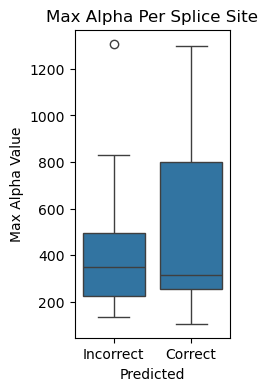

In [14]:
# Boxplot of max alpha values for correctly and incorrectly predicted splice sites
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(2, 4))
sns.boxplot(x='Correctly_Predicted', y='Alpha_max', data=results_df[results_df['True_class'] != BACKGROUND_CLASS])
plt.title("Max Alpha Per Splice Site")
plt.xlabel("Predicted")
plt.ylabel("Max Alpha Value")
#plt.yscale('log')
plt.xticks([0, 1], ['Incorrect', 'Correct'])
plt.show()

In [15]:
# How many true non-background positions?
n_trues = results_df["True_class"] != BACKGROUND_CLASS
n_false = results_df["True_class"] == BACKGROUND_CLASS
print(f"True positions: {n_trues.sum()}")
print(f"Background positions: {n_false.sum()}")

# How many are true positives (predicted non-background and true non-background)?
correct_non_bg = (results_df["Predicted_class"] == results_df["True_class"]) & (results_df["True_class"] != BACKGROUND_CLASS)
print(f"\nTrue positives: {correct_non_bg.sum()}")
for cls in range(4):
    cls_correct = (results_df["Predicted_class"] == cls) & (results_df["True_class"] == cls)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_correct.sum()} positions")

# How many are false negatives (predicted background but true non-background)?
false_negatives = (results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] != BACKGROUND_CLASS)
print(f"\nFalse negatives: {false_negatives.sum()}")
for cls in range(4):
    cls_fn = (results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] == cls)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_fn.sum()} positions")

# How many are misclassified (predicted non-background but true non-background, but predicted class is different from true class)?
misclassified = (results_df["Predicted_class"] != results_df["True_class"]) & (results_df["True_class"] != BACKGROUND_CLASS) & (results_df["Predicted_class"] != BACKGROUND_CLASS)
print(f"\nMisclassified: {misclassified.sum()}")
for cls in range(4):
    cls_mis = (results_df["Predicted_class"] == cls) & (results_df["True_class"] != cls) & (results_df["True_class"] != BACKGROUND_CLASS)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_mis.sum()} positions")

# How many are false positives (predicted non-background but true background)?
false_positives = (results_df["Predicted_class"] != BACKGROUND_CLASS) & (results_df["True_class"] == BACKGROUND_CLASS)
print(f"\nFalse positives: {false_positives.sum()}")
for cls in range(4):
    cls_fp = (results_df["Predicted_class"] == cls) & (results_df["True_class"] == BACKGROUND_CLASS)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_fp.sum()} positions")


True positions: 19
Background positions: 126273

True positives: 7
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 7 positions
  Class 3 (acceptor -): 0 positions

False negatives: 5
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 1 positions
  Class 3 (acceptor -): 4 positions

Misclassified: 7
  Class 0 (donor +): 1 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 6 positions
  Class 3 (acceptor -): 0 positions

False positives: 126273
  Class 0 (donor +): 304 positions
  Class 1 (acceptor +): 3770 positions
  Class 2 (donor -): 122194 positions
  Class 3 (acceptor -): 5 positions


In [16]:
# Summaize in a table
summary_df = pd.DataFrame({
    "Class": [CLASS_LABELS[cls] for cls in range(4)],
    "True positives": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] == cls) & (results_df["True_class"] != BACKGROUND_CLASS)).sum() for cls in range(4)],
    "False negatives": [((results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] == cls)).sum() for cls in range(4)],
    "Misclassified": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] != cls) & (results_df["True_class"] != BACKGROUND_CLASS)).sum() for cls in range(4)],
    "False positives": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] == BACKGROUND_CLASS)).sum() for cls in range(4)],
})
summary_df

,Class,True positives,False negatives,Misclassified,False positives
0,donor +,0,0,1,304
1,acceptor +,0,0,0,3770
2,donor -,7,1,6,122194
3,acceptor -,0,4,0,5


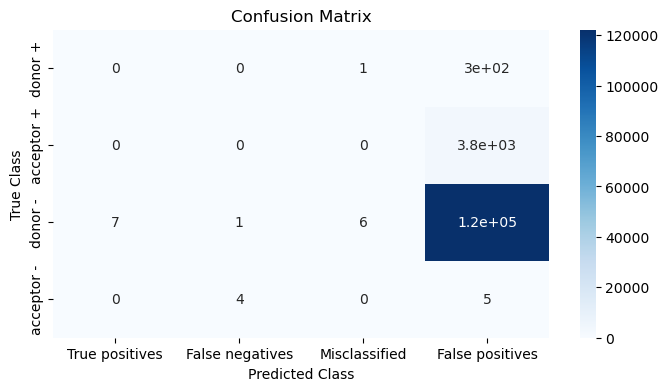

In [17]:
# Plot as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.heatmap(summary_df.set_index("Class"), annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()